# Import

In [1]:
#the usual 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, DataStructs, rdFingerprintGenerator, PandasTools, Descriptors
PandasTools.RenderImagesInAllDataFrames(images=False) # when true, it displays the structures in the DF output

#others
#from sklearn.metrics import jaccard_score
from matplotlib.colors import LogNorm
from tqdm import tqdm
from itertools import combinations

In [2]:
import rdkit
print(rdkit.__version__)

2025.09.3


# Pesticide Biodegradation dataset

## load dataset

In [3]:

# url = "https://media.githubusercontent.com/media/FennerLabs/pepper/refs/heads/main/data/soil/cpd_data_soil_all_data.tsv"
# dataset = pd.read_csv(url, sep='\t')

# downloaded it locally:
dataset = pd.read_csv('data/cpd_data_soil_all_data.tsv', sep='\t')


df = dataset[['compound_name', 'SMILES']].copy()
df['Structure'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
df

,compound_name,SMILES,Structure
0,"1,3-Dichloropropene",ClC=CCCl,<rdkit.Chem.rdchem.Mol object at 0x00000206635...
1,3-Chloroallyl alcohol,OCC=CCl,<rdkit.Chem.rdchem.Mol object at 0x00000206635...
2,3-Chloroacrylic acid,O=C([O-])C=CCl,<rdkit.Chem.rdchem.Mol object at 0x00000206635...
3,1-naphthylacetamide,NC(=O)Cc1cccc2ccccc12,<rdkit.Chem.rdchem.Mol object at 0x00000206635...
4,1-naphthoic acid (M2),O=C(O)c1cccc2ccccc12,<rdkit.Chem.rdchem.Mol object at 0x00000206635...
...,...,...,...
862,X11963422,CC1OC(=O)C(Cc2ccccc2)C1O,<rdkit.Chem.rdchem.Mol object at 0x00000206646...
863,X696476,COc1ccnc(C(=O)O)c1O,<rdkit.Chem.rdchem.Mol object at 0x00000206646...
864,XDE-777,COc1ccnc(C(=O)NC2COC(=O)C(Cc3ccccc3)C(OC(=O)C(...,<rdkit.Chem.rdchem.Mol object at 0x00000206646...
865,X642188,COc1ccnc(C(=O)NC2COC(=O)C(Cc3ccccc3)C(OC(=O)C(...,<rdkit.Chem.rdchem.Mol object at 0x00000206646...


## define generators 

In [4]:
# generators 
sizes = [256, 1024, 2048, 4096, 8192, 16384, 32768]

fp_generators = {
    "TopologicalTorsion": {
        "sparse": rdFingerprintGenerator.GetTopologicalTorsionGenerator(countSimulation=False),
        "folded": {size: rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=size,countSimulation=False) for size in sizes}
    },
    "ECFP4": {
        "sparse": rdFingerprintGenerator.GetMorganGenerator(radius=2),
        "folded": {size: rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=size) for size in sizes}
    },
    "ECFP6": {
        "sparse": rdFingerprintGenerator.GetMorganGenerator(radius=3),
        "folded": {size: rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=size) for size in sizes}
    },
    "AtomPair": {
        "sparse": rdFingerprintGenerator.GetAtomPairGenerator(countSimulation=False),
        "folded": {size: rdFingerprintGenerator.GetAtomPairGenerator(fpSize=size,countSimulation=False) for size in sizes}
    },
    "RDKit": {
        "sparse": rdFingerprintGenerator.GetRDKitFPGenerator(),
        "folded": {size: rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=size) for size in sizes}
    }
}


## Self collison count

In [ ]:
# run only once; results are stored in json collison_count

all_results = []

# loop over each generator
for fp_name, gens in fp_generators.items():
    records = []

    # calculate the number of on bits for sparse and folded for each molecule
    for mol in tqdm(df["Structure"], desc=f"Processing {fp_name}"):
        rec = {"fingerprint": fp_name}

        # sparse bits
        rec["sparse_bits"] = len(gens["sparse"].GetSparseFingerprint(mol).GetOnBits())

        # folded bits
        for size, gen in gens["folded"].items():
            rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()

        records.append(rec)

    fp_df = pd.DataFrame(records)

    # percentage of molecules where folding changed bit count
    percent_col = { size: (fp_df["sparse_bits"] != fp_df[f"folded_bits_{size}"]).sum() * 100 / len(fp_df) for size in sizes}
    
    s = pd.Series(percent_col, name=fp_name)
    all_results.append(s)

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.T

#store df
summary_df.to_json('data/pest_collision_count.json')

#display
summary_df

In [5]:
with open('data/pest_collision_count.json') as f: 
    collision_count = pd.DataFrame(json.load(f))

collision_count.index = collision_count.index.astype(int)
collision_count

,TopologicalTorsion,ECFP4,ECFP6,AtomPair,RDKit
256,53.171857,88.465975,92.733564,90.657439,98.615917
1024,20.991926,55.247982,68.627451,75.201845,97.462514
2048,15.224913,46.020761,55.478662,65.513264,97.116494
4096,7.035755,13.610150,22.145329,63.552480,95.386390
8192,3.460208,6.805075,11.880046,41.868512,94.117647
16384,0.576701,2.883506,5.767013,38.062284,90.657439
32768,0.346021,1.384083,2.652826,37.831603,83.275663


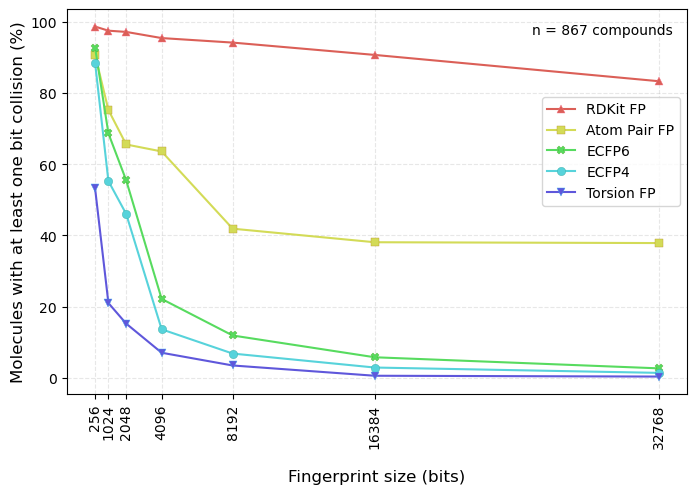

In [6]:
# %% plot the results 

labels = ["RDKit FP", "Atom Pair FP", "ECFP6" , "ECFP4" , "Torsion FP"  ]
order = ["RDKit", "AtomPair", "ECFP6" , "ECFP4" , "TopologicalTorsion"] 
markers = [ '^', 's', 'X' , 'o' , 'v', ]
n=len(df)
i=0
plt.figure(figsize=(8,5))
for fp in order:
    plt.plot(collision_count[fp], marker=markers[i], label=labels[i], color=sns.color_palette("hls")[i], markeredgecolor=sns.color_palette("husl")[i],
                    markeredgewidth=.3,)
    i=i+1

plt.xlabel("Fingerprint size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)',size=12)
plt.xticks(sizes, rotation=90, size=10)
plt.yticks(size=10)
plt.legend( bbox_to_anchor=(1, 0.79) )
plt.grid(True, linestyle="--", alpha=0.3)
plt.text( x=33600, y=96.5, s=f'n = {n} compounds', horizontalalignment = 'right')
plt.savefig('new_figures/pest_selfcol_count.svg', bbox_inches='tight')
plt.show()

## Similarity searching effects

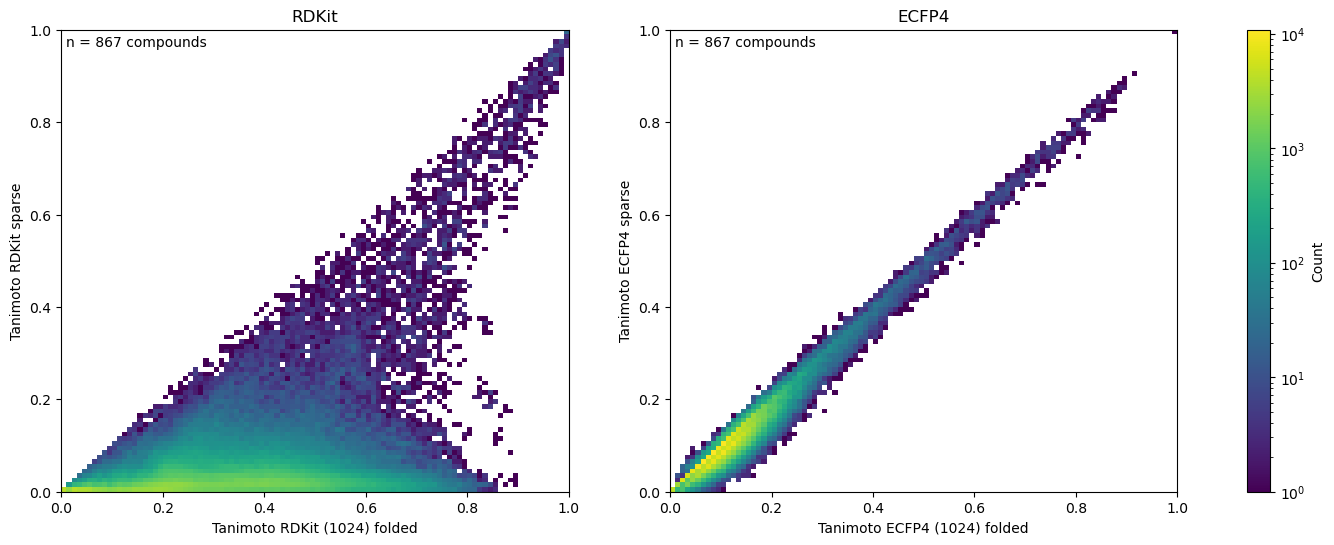

In [7]:
mols = df.Structure
n = len(mols)

# ECFP4 
ecfp4 = [rdFingerprintGenerator.GetMorganGenerator(radius = 2, fpSize=1024).GetFingerprint(m) for m in mols]
sparse_ecfp4 = [rdFingerprintGenerator.GetMorganGenerator(radius=2).GetSparseFingerprint(m) for m in mols]
counts_ecfp4 = np.zeros((100, 100))

# loop over molecules, compare against all later ones
for i in range(n):
    sims_fold = DataStructs.BulkTanimotoSimilarity(ecfp4[i], ecfp4[i+1:])
    sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_ecfp4[i], sparse_ecfp4[i+1:])
    
    # update histogram 
    hist, _, _ = np.histogram2d(
        sims_fold, sims_sparse,
        bins=100, range=[[0,1],[0,1]]
    )
    counts_ecfp4 += hist

counts_masked_ecfp4 = np.ma.masked_where(counts_ecfp4 == 0, counts_ecfp4)

# RDKit 
rdkitfp = [rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=1024).GetFingerprint(m) for m in mols]
sparse_rdkitfp= [rdFingerprintGenerator.GetRDKitFPGenerator().GetSparseFingerprint(m) for m in mols]
counts_rdkit = np.zeros((100, 100))

for i in range(n):
    sims_fold = DataStructs.BulkTanimotoSimilarity(rdkitfp[i], rdkitfp[i+1:])
    sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_rdkitfp[i], sparse_rdkitfp[i+1:])
    
    # update histogram 
    hist, _, _ = np.histogram2d(
        sims_fold, sims_sparse,
        bins=100, range=[[0,1],[0,1]]
    )
    counts_rdkit += hist

counts_masked_rdkit = np.ma.masked_where(counts_rdkit == 0, counts_rdkit)


# colour scale 
vmax = max(counts_ecfp4.max(),counts_rdkit.max())
norm = LogNorm(vmin=1,vmax=vmax)


# figure

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)

# RDKit
im1 = axes[0].pcolormesh(
    x,
    y,
    counts_masked_rdkit.T,
    cmap="viridis",
    norm=norm
)

axes[0].set_xlabel("Tanimoto RDKit (1024) folded")
axes[0].set_ylabel("Tanimoto RDKit sparse")
axes[0].set_title("RDKit")
axes[0].text(0.01, 0.965, f"n = {n} compounds")

# ECFP4
im2 = axes[1].pcolormesh(
    x,
    y,
    counts_masked_ecfp4.T,
    cmap="viridis",
    norm=norm)

axes[1].set_xlabel("Tanimoto ECFP4 (1024) folded")
axes[1].set_ylabel("Tanimoto ECFP4 sparse")
axes[1].set_title("ECFP4")
axes[1].text(0.01, 0.965, f"n = {n} compounds")


fig.colorbar(
    im1,
    ax=axes,
    label="Count",
)

plt.savefig('new_figures/comb_scale_sim_plot.svg', bbox_inches='tight')
plt.show()


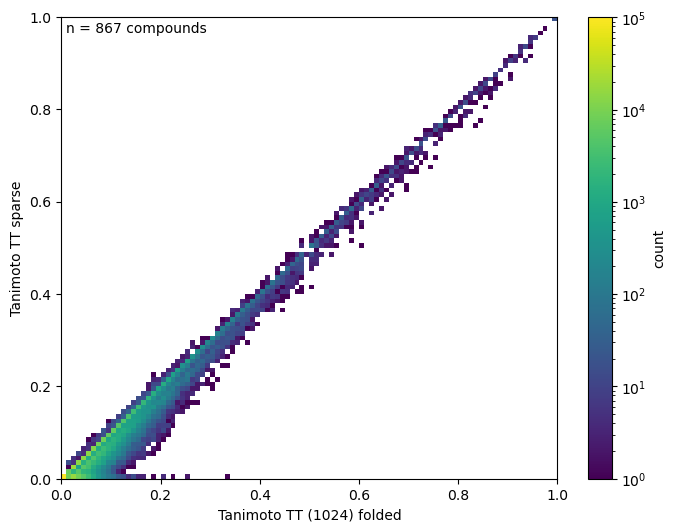

In [8]:
## topological torsion 

mols = df.Structure
n = len(mols)

# fingerprints
TT = [rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=1024,countSimulation=False).GetFingerprint(m) for m in mols]
sparse_TT = [rdFingerprintGenerator.GetTopologicalTorsionGenerator(countSimulation=False).GetSparseFingerprint(m) for m in mols]


# initialize histogram
counts = np.zeros((100, 100))

# loop over molecules, compare against all later ones
for i in range(n):
    sims_fold = DataStructs.BulkTanimotoSimilarity(TT[i], TT[i+1:])
    sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_TT[i], sparse_TT[i+1:])
    
    # update histogram 
    hist, _, _ = np.histogram2d(
        sims_fold, sims_sparse,
        bins=100, range=[[0,1],[0,1]]
    )
    counts += hist

# mask zero-count bins
counts_masked = np.ma.masked_where(counts == 0, counts)

# plot
plt.figure(figsize=(8, 6))

plt.pcolormesh(
    np.linspace(0,1,101),
    np.linspace(0,1,101),
    counts_masked.T,
    cmap="viridis",
    norm=LogNorm(vmin=1, vmax=counts.max())) # log scale is needed

plt.colorbar(label="count")
plt.xlabel("Tanimoto TT (1024) folded")
plt.ylabel("Tanimoto TT sparse")
plt.text( x= 0.01, y=0.965,  s=f'n = {n} compounds')
#plt.savefig('new_figures/pesticide_TT_sim_plot.svg', bbox_inches='tight')
plt.show()


# Large general dataset

## Load dataset, curate and move to pickle 

In [ ]:
# load data from the zero pm github
url = "https://raw.githubusercontent.com/ZeroPM-H2020/global-chemical-inventory-database/refs/heads/main/csv_files/substances.csv"
df = pd.read_csv(url)

# inchi to structure 
df[  "Structure"  ] = df[  "inchi"  ].apply(lambda x: Chem.inchi.MolFromInchi(x))

# drop everything that doesnt work 
to_drop = df.loc[df[  "Structure"  ].isnull() == True].index
df = df.drop(to_drop)
df.shape

# safe the new df
zeropm_substances = "zeropm_substances.csv"
df.to_csv(zeropm_substances, index=False)

In [ ]:
import operator as op

# import dataframe of the compounds without errors
df = pd.read_csv("zeropm_substances.csv")

#remove salts  
df[  "Salt"  ] = df[  inchi  ].apply(lambda x: op.contains(x, "." ))
df = df.loc[df[  "Salt"  ] == False]

# re-run structure as this doesnt save in csv
df[  "Structure"  ] = df[  "inchi"  ].apply(lambda x: Chem.inchi.MolFromInchi(x, sanitize=True, removeHs=True))

# remove the single atoms and diatoms
df[  "NumAtoms"  ] = df[  "Structure"  ].apply(lambda x: x.GetNumAtoms())
df = df.loc[df[  "NumAtoms"  ] > 2]

df = df.set_index(  "inchi_id"  )
df.shape

In [ ]:
# safe df in pickle so the molfrominchi does not have to be rerun
df.to_pickle("./substances.pkl")  

## Load data

In [9]:
df_gen = pd.read_pickle("data/substances.pkl") 
df_gen

,inchi,inchikey,Structure,Salt,NumAtoms
inchi_id,,,,,
1,InChI=1S/C6H4ClNO2/c7-5-1-3-6(4-2-5)8(9)10/h1-4H,CZGCEKJOLUNIFY-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x000002066C7...,False,10
2,InChI=1S/C6H6N2O2/c7-5-1-3-6(4-2-5)8(9)10/h1-4...,TYMLOMAKGOJONV-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x000002066C7...,False,10
3,"InChI=1S/C6H5NO3/c8-6-3-1-5(2-4-6)7(9)10/h1-4,8H",BTJIUGUIPKRLHP-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x000002066C7...,False,10
4,InChI=1S/C6H5ClO2S/c7-5-1-3-6(4-2-5)10(8)9/h1-...,AOQYAMDZQAEDLO-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x000002066C7...,False,10
7,InChI=1S/C9H10O2/c1-7(10)8-3-5-9(11-2)6-4-8/h3...,NTPLXRHDUXRPNE-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x000002066C7...,False,11
...,...,...,...,...,...
359105,"InChI=1S/O6Si2/c1-7(2)6-8(3,4)5/q-4",NYRJGAMJBNFXOM-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x00000206B4C...,False,8
359107,"InChI=1S/O7Si2/c1-8(2,3)7-9(4,5)6/q-6",KUDCBYUNCUYIDU-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x00000206B4C...,False,9
359108,InChI=1S/O7Si3/c1-8(2)6-10(5)7-9(3)4/q-2,MXSSWTMUAUJAKG-UHFFFAOYSA-N,<rdkit.Chem.rdchem.Mol object at 0x00000206B2B...,False,10


## Self collision count

In [ ]:
# run only once; results are stored in json collison_count

all_results = []

# loop over each generator
for fp_name, gens in fp_generators.items():
    records = []

    # calculate the number of on bits for sparse and folded for each molecule
    for mol in tqdm(df_gen["Structure"], desc=f"Processing {fp_name}"):
        rec = {"fingerprint": fp_name}

        # sparse bits
        rec["sparse_bits"] = len(gens["sparse"].GetSparseFingerprint(mol).GetOnBits())

        # folded bits
        for size, gen in gens["folded"].items():
            rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()

        records.append(rec)

    fp_df = pd.DataFrame(records)

    # percentage of molecules where folding changed bit count
    percent_col = { size: (fp_df["sparse_bits"] != fp_df[f"folded_bits_{size}"]).sum() * 100 / len(fp_df) for size in sizes}
    
    s = pd.Series(percent_col, name=fp_name)
    all_results.append(s)

summary_df = pd.DataFrame(all_results)
summary_df = summary_df.T

#store df
summary_df.to_json('data/general_collision_count.json')

#display
summary_df

In [10]:
with open('data/general_collision_count.json') as f: 
    gen_collision_count = pd.DataFrame(json.load(f))

gen_collision_count.index = gen_collision_count.index.astype(int)
gen_collision_count


,TopologicalTorsion,ECFP4,ECFP6,AtomPair,RDKit
256,42.076076,80.328636,88.014726,85.843285,98.634486
1024,17.820128,46.978545,58.691180,63.257587,95.897658
2048,12.646954,37.989589,46.502877,44.283096,92.885097
4096,8.092148,10.023049,18.532082,39.362064,88.550722
8192,6.474105,6.102852,11.187854,23.856851,84.515283
16384,1.644727,2.847044,5.947390,19.354639,79.724190
32768,0.806314,1.080500,2.437893,19.104430,70.465303


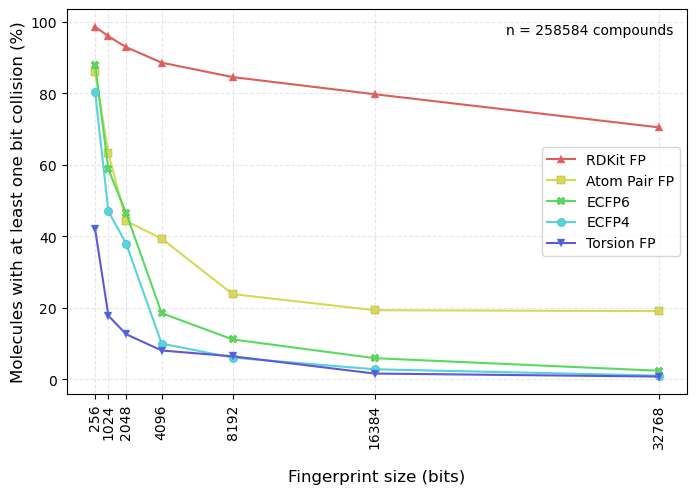

In [11]:
labels = ["RDKit FP", "Atom Pair FP", "ECFP6" , "ECFP4" , "Torsion FP"  ]
order = ["RDKit", "AtomPair", "ECFP6" , "ECFP4" , "TopologicalTorsion"] 
markers = [ '^', 's', 'X' , 'o' , 'v', ]
n=len(df_gen)

i=0
plt.figure(figsize=(8,5))
for fp in order:
    plt.plot(gen_collision_count[fp], marker=markers[i], label=labels[i], color=sns.color_palette("hls")[i], markeredgecolor=sns.color_palette("husl")[i],
                    markeredgewidth=.3,)
    i=i+1

plt.xlabel("Fingerprint size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)',size=12)
plt.xticks(sizes, rotation=90, size=10)
plt.yticks(size=10)
plt.legend( )
plt.grid(True, linestyle="--", alpha=0.3)
plt.text( x=33600, y=96.5, s=f'n = {n} compounds', horizontalalignment = 'right')
plt.savefig('new_figures/general_selfcol_count.svg', bbox_inches='tight')
plt.show()

### per size class

In [12]:
def size(x):
    if x<20: 
        return 'x-small'
    if x<75:
        return 'small'
    if x<200:
        return 'medium'
    else:
        return 'large'

df_gen['Size'] = df_gen['NumAtoms'].apply(lambda x: size(x))
grouped_wt = df_gen.groupby('Size')
grouped_wt.size()

Size
large         208
medium       2386
small       97432
x-small    158558
dtype: int64

In [ ]:

# run ECFP4 for different sized molecules and save as json 

sizes = [256, 1024, 2048, 4096, 8192, 16384, 32768]
fp_gen_sparse = rdFingerprintGenerator.GetMorganGenerator(radius=2)
fp_gens_folded = {size: rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=size) for size in sizes}


summary_rows = []

for size_class, group in grouped_wt:

    records = []
    
    # loop over molecules with tqdm progress bar
    for mol in tqdm(group['Structure'], desc=f"Processing molecules for class {size_class}"):
        rec = {}
        
        # sparse bits count
        rec["sparse_bits"] = len(fp_gen_sparse.GetSparseFingerprint(mol).GetOnBits())
        
        # folded bits counts
        for size, gen in fp_gens_folded.items():
            rec[f"folded_bits_{size}"] = gen.GetFingerprint(mol).GetNumOnBits()
        records.append(rec)
    
    bit_col_df = pd.DataFrame(records)

    row = {"Size class": size_class}
    for size in sizes:
        row[size] = ((bit_col_df["sparse_bits"] != bit_col_df[f"folded_bits_{size}"]).mean()* 100)

    summary_rows.append(row)

size_df = pd.DataFrame(summary_rows)

size_df = size_df.set_index('Size class')
size_df = size_df.T

size_df.to_json('data/general_count_weight_ECFP4.json')

size_df


In [16]:
with open('data/general_count_weight_ECFP4.json') as f: 
    size_df_ecfp4 = pd.DataFrame(json.load(f))

size_df_ecfp4.index = size_df_ecfp4.index.astype(int)
size_df_ecfp4

,large,medium,small,x-small
256,99.519231,97.359598,94.293456,71.465962
1024,97.115385,84.534786,64.346416,35.675273
2048,95.192308,79.882649,53.850891,27.537557
4096,56.730769,41.072925,18.011536,4.585704
8192,55.288462,28.792959,11.146235,2.597788
16384,27.884615,16.512992,5.125626,1.208391
32768,27.403846,7.544007,2.016791,0.373365


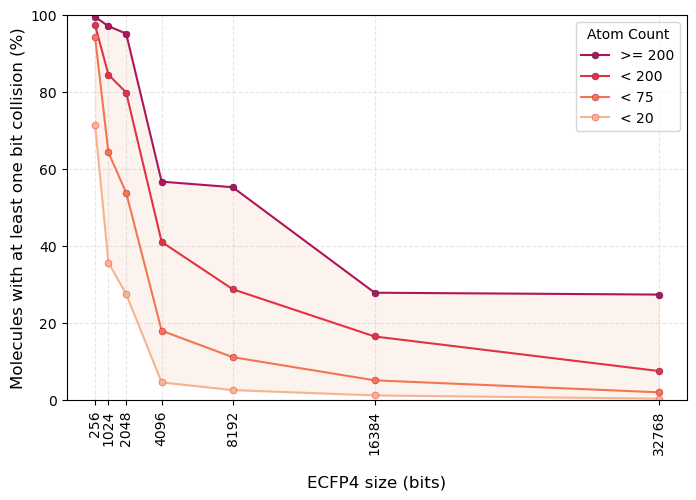

In [94]:

labels = ['>= 200', '< 200' , '< 75' , '< 20' ]

i=0
plt.figure(figsize=(8,5))
for col in size_df_ecfp4.columns:
    plt.plot(size_df_ecfp4[col], label=labels[i], marker = '.', markersize = 10,  color=sns.color_palette("rocket")[i+2], markeredgecolor=sns.color_palette("rocket")[i],
                    markeredgewidth=.3,)
    i=i+1

top = size_df_ecfp4.iloc[:, 0]
bottom = size_df_ecfp4.iloc[:, -1]

plt.fill_between(size_df_ecfp4.index, top, bottom, color=sns.color_palette("rocket")[i+1], alpha=0.15)

plt.xlabel("ECFP4 size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)',size=12)

plt.xticks(sizes, rotation=90, size=10)
plt.yticks(size=10)
plt.ylim(0,100)
plt.legend( title='Atom Count' )
plt.grid(True, linestyle="--", alpha=0.3)
plt.savefig('new_figures/general_selfcol_pw.svg', bbox_inches='tight')

plt.show()

In [27]:
with open('data/general_count_weight_ecfp6.json') as f: 
    size_df_ecfp6 = pd.DataFrame(json.load(f))

size_df_ecfp6.index = size_df_ecfp6.index.astype(int)
size_df_ecfp6

,large,medium,small,x-small
256,99.519231,99.455155,98.077634,81.643941
1024,97.115385,90.611903,78.931973,45.722701
2048,97.115385,86.630344,65.876714,33.927648
4096,93.750000,67.141660,32.418507,9.168885
8192,92.788462,54.819782,19.959562,5.034120
16384,92.307692,38.222967,10.537606,2.527782
32768,69.230769,22.673931,4.335331,0.879804


In [23]:
with open('data/general_count_weight_TT.json') as f: 
    size_df_TT = pd.DataFrame(json.load(f))

size_df_TT.index = size_df_TT.index.astype(int)
size_df_TT

,large,medium,small,x-small
256,95.673077,81.265717,62.791485,28.686664
1024,87.980769,56.328583,32.698703,8.005903
2048,87.500000,45.473596,23.232614,5.550020
4096,86.538462,28.206203,14.937598,3.480115
8192,86.057692,24.266555,11.807209,2.824834
16384,85.096154,11.399832,2.898432,0.618070
32768,6.250000,6.035205,1.210075,0.472382


In [18]:
with open('data/general_count_weight_AtomPair.json') as f: 
    size_df_AP = pd.DataFrame(json.load(f))

size_df_AP.index = size_df_AP.index.astype(int)
size_df_AP

,large,medium,small,x-small
256,100.000000,99.664711,98.623655,77.763342
1024,100.000000,99.077955,89.101117,46.789818
2048,99.519231,97.988265,70.925363,27.031118
4096,99.519231,91.072925,60.996387,25.210964
8192,97.596154,85.121542,46.141925,9.144288
16384,95.192308,78.164292,37.285491,7.351884
32768,93.750000,76.404023,36.688152,7.339270


In [24]:
with open('data/general_count_weight_RDkit.json') as f: 
    size_df_RDkit = pd.DataFrame(json.load(f))

size_df_RDkit.index = size_df_RDkit.index.astype(int)
size_df_RDkit

,large,medium,small,x-small
256,100.000000,99.874267,99.857336,97.862612
1024,100.000000,99.874267,99.070121,93.882995
2048,99.519231,99.077955,97.696855,89.826436
4096,99.519231,98.910310,96.283562,83.628704
8192,99.519231,98.575021,94.799450,77.964530
16384,97.596154,96.689019,92.582519,71.544167
32768,96.634615,93.797150,87.332704,59.715057


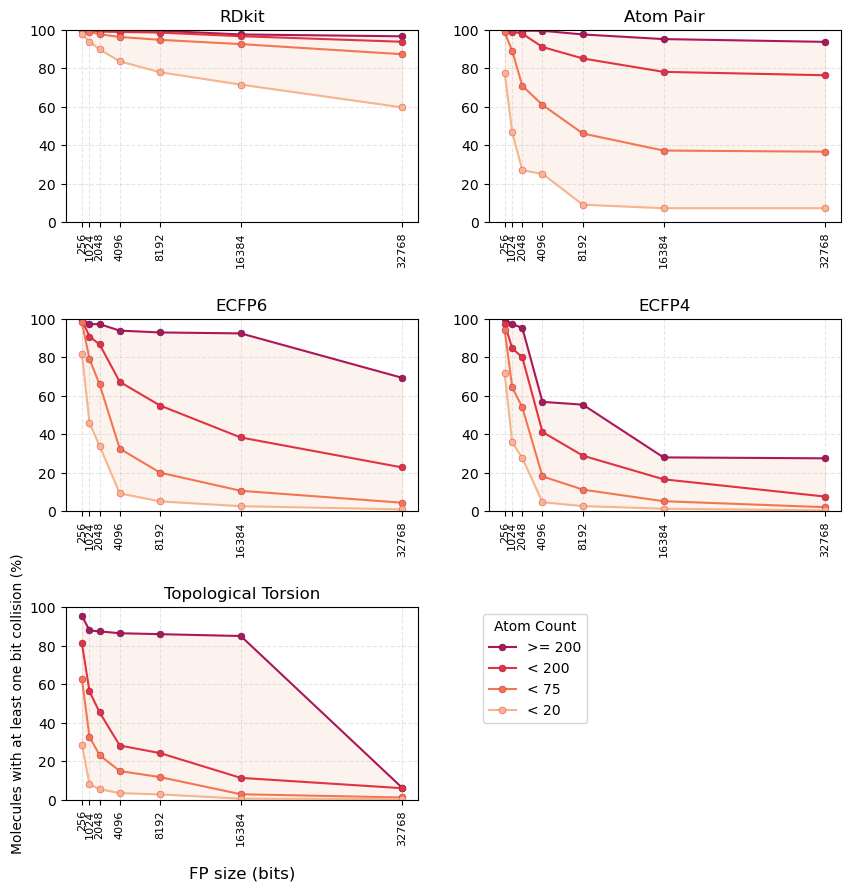

In [90]:
size_dfs = [size_df_RDkit , size_df_AP, size_df_ecfp6, size_df_ecfp4, size_df_TT ] 
titels = ["RDkit" , "Atom Pair", "ECFP6", "ECFP4", "Topological Torsion" ]
labels = ['>= 200', '< 200' , '< 75' , '< 20' ]

plt.figure(figsize=(10,10))
plt.subplots_adjust(hspace=0.5)
k=0
for n, size_df in enumerate(size_dfs):
    i=0
    ax = plt.subplot(3, 2, n + 1)
    for col in size_df.columns:
        plt.plot(size_df[col], label=labels[i], marker = '.', markersize = 10,  color=sns.color_palette("rocket")[i+2], markeredgecolor=sns.color_palette("rocket")[i],
                        markeredgewidth=.3,)
        i=i+1

    top = size_df.iloc[:, 0]
    bottom = size_df.iloc[:, -1]

    ax.fill_between(size_df.index, top, bottom, color=sns.color_palette("rocket")[i+1], alpha=0.15)
    ax.set_title(titels[k])
    k=k+1
    plt.xticks(sizes, rotation=90, size=8)
    # plt.yticks(size=8)
    plt.ylim(0,100)
    # 
    plt.grid(True, linestyle="--", alpha=0.3)
    
plt.xlabel("FP size (bits)", size=12, labelpad=15)
plt.ylabel('Molecules with at least one bit collision (%)')
plt.legend( title='Atom Count' , bbox_to_anchor=(1.5, 1) )

# plt.savefig('new_figures/allfp_selfcol_pw.svg', bbox_inches='tight')
plt.show()



## Similarity searching effect 

In [ ]:
# define
df_sample = df_gen.sample(n=5000, random_state=42)
mols = df_sample.Structure
n = len(mols)

sizes = [256, 1024, 2048, 4096, 8192]

for fp_name, gens in fp_generators.items():

    # sparse fingerprints
    sparse_fp = [gens["sparse"].GetSparseFingerprint(m) for m in mols]

    # folded fingerprints
    fingerprints = {size: [gens["folded"][size].GetFingerprint(m) for m in mols] for size in sizes}
    
    # subplot grid
    fig, axes = plt.subplots(1, len(sizes), figsize=(6*len(sizes), 4), sharex=True, sharey=True)
    
    for ax, size in zip(axes, sizes):
        fp = fingerprints[size]
        counts = np.zeros((100, 100))
    
        # make the 2d historgram
        for i in tqdm(range(n), desc=f"Processing fpSize={size}", unit="mol"):
            sims_fold = DataStructs.BulkTanimotoSimilarity(fp[i], fp[i+1:])
            sims_sparse = DataStructs.BulkTanimotoSimilarity(sparse_fp[i], sparse_fp[i+1:])
            
            hist, _, _ = np.histogram2d(
                sims_fold, sims_sparse,
                bins=100, range=[[0,1],[0,1]]
            )
            counts += hist
    
        # mask zero-count bin
        counts_masked = np.ma.masked_where(counts == 0, counts)
    
        # subplot
        mesh = ax.pcolormesh(
            np.linspace(0,1,101),
            np.linspace(0,1,101),
            counts_masked.T,
            cmap="viridis",
            norm=LogNorm(vmin=1, vmax=counts.max())
        )
        ax.set_xlabel(f"Tanimoto folded")
        ax.set_ylabel(f"Tanimoto sparse")
        ax.set_title(f"{fp_name}; {size} bits")
    
    #one shared colorbar
    fig.colorbar(mesh, ax=axes, label="count", pad=0.02)
    #  fig.suptitle(f"Similarity scores for unfolded vs folded {fp_name} for {n} compounds", fontsize=20, y=1.1, x=0.2)
    plt.savefig(f"new_figures/gen_{fp_name}_similarity.svg", bbox_inches="tight")
    plt.show()

# Machine learning Figures

In [ ]:
with open('data/model_results.json', 'r') as f:
    model_output = json.load(f)

In [ ]:
order = ['map4', 'rdkit', 'secfp6', 'ecfp4']

rows = []
for key, split_dict in model_output.items():
    model_type, encoding, bitlen = key.rsplit("_", 2)
    bitlen = int(bitlen)
    for split_idx, metrics in split_dict.items():
        mae = metrics.get("mae", None)
        if mae is not None:
            rows.append({
                "model_type": model_type,
                "encoding": encoding,
                "bits": bitlen,
                "split": int(split_idx),
                "mae": mae
            })

df = pd.DataFrame(rows)

mean_mae_df = df.groupby(["model_type", "encoding", "bits"])["mae"].mean().reset_index()
mean_mae_df['std'] = df.groupby(["model_type", "encoding", "bits"])["mae"].std().reset_index()['mae']


for model_type, model_df in mean_mae_df.groupby("model_type"):
    pivot_df_mean = model_df.pivot(index="encoding", columns="bits", values="mae").sort_index(axis=1)
    pivot_df_mean = pivot_df_mean.reindex(order)

    pivot_df_std = model_df.pivot(index="encoding", columns="bits", values="std").sort_index(axis=1)
    pivot_df_std = pivot_df_std.reindex(order)

    
    fig, ax = plt.subplots(figsize=(8,5))
    
    # styles = {
    #     "map4": {"marker": "s", "color": 'red'},
    #     "rdkit": {"marker": "^", "color": 'orange'},
    #     "secfp6": {"marker": "v", "color": 'green'},
    #     "ecfp4": {"marker": "o", "color": 'blue'}
    # }


    # styles = {
    #     "map4": {"marker": "s", "color": '#EF436B', 'markeredgecolor': '#BC1038', 'markeredgewidth': .3},
    #     "rdkit": {"marker": "^", "color": '#FFC847', 'markeredgecolor': '#E09D00', 'markeredgewidth': .3},
    #     "secfp6": {"marker": "v", "color": '#06D6A0', 'markeredgecolor': '#058A66', 'markeredgewidth': .3},
    #     "ecfp4": {"marker": "o", "color": '#1082A8', 'markeredgecolor': '#0C6583', 'markeredgewidth': .3}
    # }

    styles = {
        "map4": {"marker": "s", "color": '#0C6583', 'markeredgecolor': '#073A4B', 'markeredgewidth': .3},
        "rdkit": {"marker": "^", "color": '#ED315D', 'markeredgecolor': '#E11444', 'markeredgewidth': .3},
        "secfp6": {"marker": "v", "color": '#06DBA2', 'markeredgecolor': '#049F76', 'markeredgewidth': .3},
        "ecfp4": {"marker": "o", "color": '#FFC847', 'markeredgecolor': '#E09D00', 'markeredgewidth': .3}
    }
    
    for encoding, row in pivot_df_mean.iterrows():
        x = pivot_df_mean.columns.tolist()
        y = row.values.astype(float)
        ax.plot(x, y, label=encoding, **styles.get(encoding))


    # x = pivot_df_mean.columns.tolist()
    # for encoding in order:
    #     plt.errorbar(
    #         x= x,
    #         y = pivot_df_mean.loc[encoding],
    #         yerr=pivot_df_std.loc[encoding],
    #         label=encoding,
    #         **styles.get(encoding),
    #     )

    # ax.set_ylim(0.585, 0.75)
    ax.set_xlabel("Fingerprint size (bits)", size=12, labelpad=15)
    ax.set_ylabel(f"Mean MAE across splits ({model_type})",size=12)
    ax.set_xticks(pivot_df_mean.columns)
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(f"new_figures/mean_mae_{model_type}_pesticides.svg")


In [ ]:
with open('data/model_results_lipo.json', 'r') as f:
    model_output = json.load(f)

In [ ]:
order = ['map4', 'rdkit', 'secfp6', 'ecfp4']

rows = []
for key, split_dict in model_output.items():
    model_type, encoding, bitlen = key.rsplit("_", 2)
    bitlen = int(bitlen)
    for split_idx, metrics in split_dict.items():
        mae = metrics.get("mae", None)
        if mae is not None:
            rows.append({
                "model_type": model_type,
                "encoding": encoding,
                "bits": bitlen,
                "split": int(split_idx),
                "mae": mae
            })

df = pd.DataFrame(rows)

mean_mae_df = df.groupby(["model_type", "encoding", "bits"])["mae"].mean().reset_index()
mean_mae_df['std'] = df.groupby(["model_type", "encoding", "bits"])["mae"].std().reset_index()['mae']


for model_type, model_df in mean_mae_df.groupby("model_type"):
    pivot_df_mean = model_df.pivot(index="encoding", columns="bits", values="mae").sort_index(axis=1)
    pivot_df_mean = pivot_df_mean.reindex(order)

    pivot_df_std = model_df.pivot(index="encoding", columns="bits", values="std").sort_index(axis=1)
    pivot_df_std = pivot_df_std.reindex(order)

    
    fig, ax = plt.subplots(figsize=(8,5))


    styles = {
        "map4": {"marker": "s", "color": '#0C6583', 'markeredgecolor': '#073A4B', 'markeredgewidth': .3},
        "rdkit": {"marker": "^", "color": '#ED315D', 'markeredgecolor': '#E11444', 'markeredgewidth': .3},
        "secfp6": {"marker": "v", "color": '#06DBA2', 'markeredgecolor': '#049F76', 'markeredgewidth': .3},
        "ecfp4": {"marker": "o", "color": '#FFC847', 'markeredgecolor': '#E09D00', 'markeredgewidth': .3}
    }

    
    
    for encoding, row in pivot_df_mean.iterrows():
        x = pivot_df_mean.columns.tolist()
        y = row.values.astype(float)
        ax.plot(x, y, label=encoding, **styles.get(encoding))


    # x = pivot_df_mean.columns.tolist()
    # for encoding in order:
    #     plt.errorbar(
    #         x= x,
    #         y = pivot_df_mean.loc[encoding],
    #         yerr=pivot_df_std.loc[encoding],
    #         label=encoding,
    #         **styles.get(encoding),
    #     )

    # ax.set_ylim(0.585, 0.75)
    ax.set_xlabel("Fingerprint size (bits)", size=12, labelpad=15)
    ax.set_ylabel(f"Mean MAE across splits ({model_type})",size=12)
    ax.set_xticks(pivot_df_mean.columns)
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)

    fig.tight_layout()
    fig.savefig(f"new_figures/mean_mae_{model_type}_lipo.svg")

